<a href="https://colab.research.google.com/github/Tahmidro/phitronNotebooks/blob/main/knn_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler,OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score


In [ ]:
df=load_wine(as_frame=True).frame

df.sample(6)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
101,12.60,1.34,1.90,18.5,88.0,1.45,1.36,0.29,1.35,2.45,1.04,2.77,562.0,1
15,13.63,1.81,2.70,17.2,112.0,2.85,2.91,0.30,1.46,7.30,1.28,2.88,1310.0,0
140,12.93,2.81,2.70,21.0,96.0,1.54,0.50,0.53,0.75,4.60,0.77,2.31,600.0,2
82,12.08,1.13,2.51,24.0,78.0,2.00,1.58,0.40,1.40,2.20,1.31,2.72,630.0,1
81,12.72,1.81,2.20,18.8,86.0,2.20,2.53,0.26,1.77,3.90,1.16,3.14,714.0,1
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2


<Axes: xlabel='target', ylabel='count'>

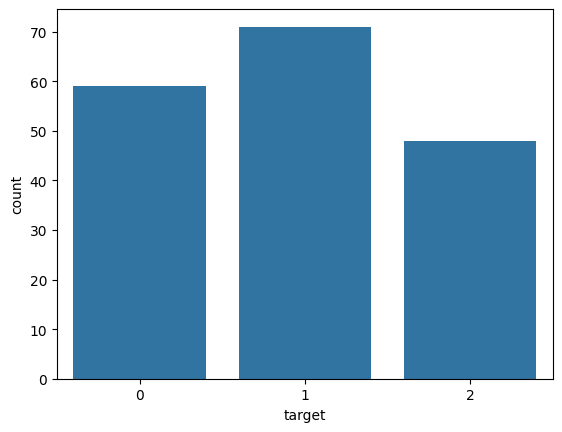

In [ ]:
sns.countplot(data=df,x="target")

In [ ]:
X=df.drop('target',axis=1)
y=df['target']

Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
knnModel=Pipeline(
    steps=[
        ("scaler",StandardScaler()),
        ("knn",KNeighborsClassifier(n_neighbors=16,metric="minkowski",p=2))
    ]


)
knnModel.fit(Xtrain,ytrain)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=16))])

In [ ]:
knnModel.score(Xtest,ytest)

1.0

In [ ]:
ypred=knnModel.predict(Xtest)
confMatrix=confusion_matrix(ytest,ypred)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



best settings check


In [ ]:
performance2=[]
for k in range(4,30):
    knnModel=Pipeline(
    steps=[
        ("scaler",StandardScaler()),
        ("knn",KNeighborsClassifier(n_neighbors=k,metric="minkowski",p=2))
    ]
  )
    knnModel.fit(Xtrain,ytrain)
    ypred=knnModel.predict(Xtest)
    accuracy=round(accuracy_score(ytest,ypred),4)
    precision=round(precision_score(ytest,ypred,average="weighted"),4)
    recall=round(recall_score(ytest,ypred,average="weighted"),4)
    performance2.append((k,accuracy,precision,recall))



In [ ]:
performance2=pd.DataFrame(performance2,columns=["k","accuracy","precision","recall"])
display(performance2)

,k,accuracy,precision,recall
0,4,0.9444,0.9466,0.9444
1,5,0.9722,0.9747,0.9722
2,6,0.9722,0.9741,0.9722
3,7,1.0000,1.0000,1.0000
4,8,1.0000,1.0000,1.0000
5,9,1.0000,1.0000,1.0000
6,10,1.0000,1.0000,1.0000
7,11,1.0000,1.0000,1.0000
8,12,1.0000,1.0000,1.0000
9,13,1.0000,1.0000,1.0000


In [ ]:
performance1=[]
for k in range(4,30):
    knnModel=Pipeline(
    steps=[
        ("scaler",StandardScaler()),
        ("knn",KNeighborsClassifier(n_neighbors=k,metric="minkowski",p=1))
    ]
  )
    knnModel.fit(Xtrain,ytrain)
    ypred=knnModel.predict(Xtest)
    accuracy=round(accuracy_score(ytest,ypred),4)
    precision=round(precision_score(ytest,ypred,average="weighted"),4)
    recall=round(recall_score(ytest,ypred,average="weighted"),4)
    performance1.append((k,accuracy,precision,recall))


In [ ]:
performance1=pd.DataFrame(performance1,columns=["k","accuracy","precision","recall"])
display(performance1)

,k,accuracy,precision,recall
0,4,0.9722,0.9744,0.9722
1,5,1.0000,1.0000,1.0000
2,6,1.0000,1.0000,1.0000
3,7,1.0000,1.0000,1.0000
4,8,1.0000,1.0000,1.0000
5,9,1.0000,1.0000,1.0000
6,10,0.9722,0.9744,0.9722
7,11,0.9722,0.9744,0.9722
8,12,0.9722,0.9744,0.9722
9,13,0.9722,0.9744,0.9722


### Visualizing Model Performance (Accuracy, Precision, Recall) for different 'k' values and 'p' metrics

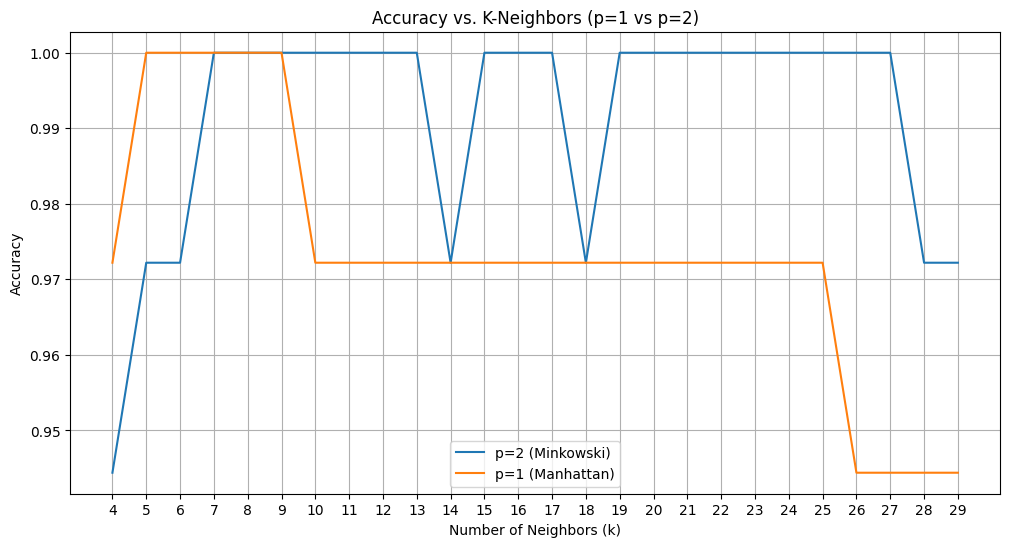

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=performance2, x='k', y='accuracy', label='p=2 (Minkowski)')
sns.lineplot(data=performance1, x='k', y='accuracy', label='p=1 (Manhattan)')
plt.title('Accuracy vs. K-Neighbors (p=1 vs p=2)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(range(4, 30))
plt.grid(True)
plt.legend()
plt.show()

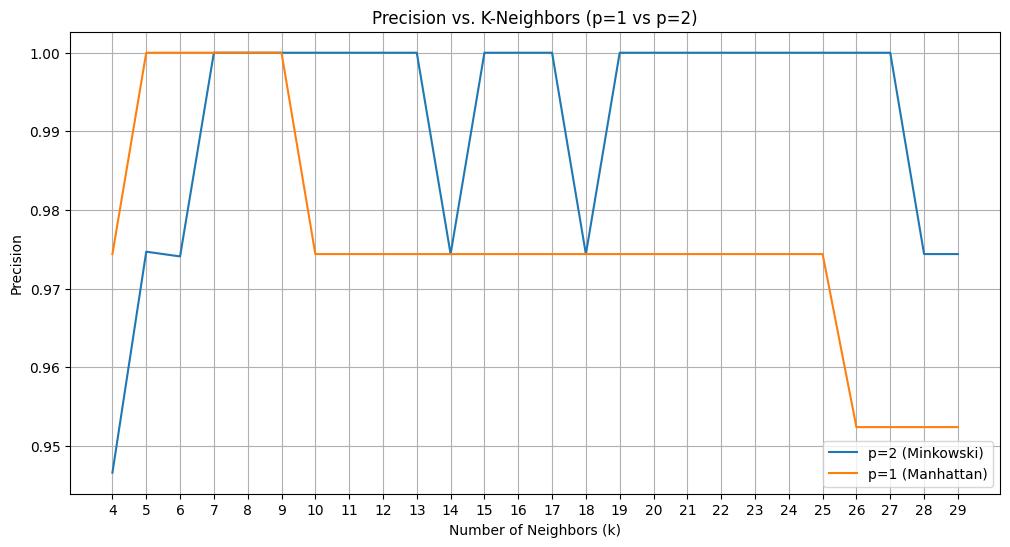

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=performance2, x='k', y='precision', label='p=2 (Minkowski)')
sns.lineplot(data=performance1, x='k', y='precision', label='p=1 (Manhattan)')
plt.title('Precision vs. K-Neighbors (p=1 vs p=2)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Precision')
plt.xticks(range(4, 30))
plt.grid(True)
plt.legend()
plt.show()

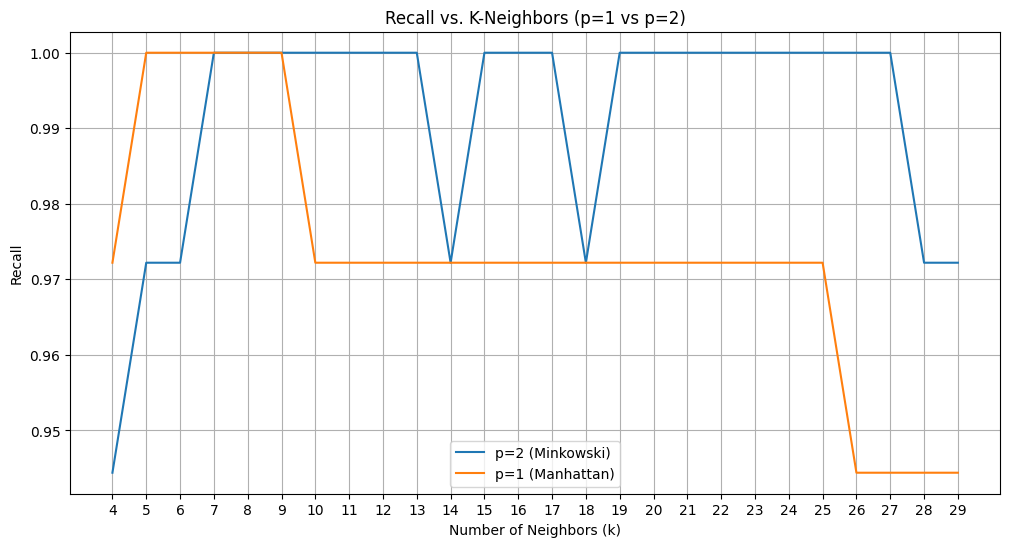

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=performance2, x='k', y='recall', label='p=2 (Minkowski)')
sns.lineplot(data=performance1, x='k', y='recall', label='p=1 (Manhattan)')
plt.title('Recall vs. K-Neighbors (p=1 vs p=2)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Recall')
plt.xticks(range(4, 30))
plt.grid(True)
plt.legend()
plt.show()